In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    learning_curve
)

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from sklearn.ensemble import (
    AdaBoostClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

from sklearn.cluster import (
    KMeans
)

from sklearn.mixture import GaussianMixture

import xgboost as xgb

In [3]:
df = pd.read_csv("../data/numeric_pattern.csv")

df.head()

,Feature_1_Age,Feature_2_Income,Feature_3_Experience,Feature_4_Education,Feature_5_Skill,Feature_6_Performance,Feature_7_Projects,Feature_8_Attendance,Feature_9_TrainingHours,Feature_10_IQ,Target
0,60.0,250533.570765,40.0,51.0,87.0,67.0,8.0,74.0,45.0,114.99086,38012.809185
1,54.0,223288.442691,34.0,87.0,67.0,52.0,1.0,65.0,65.0,109.00000,33979.169389
2,52.0,196879.233126,28.0,51.0,75.0,62.0,18.0,86.0,66.0,137.00000,29926.071273
3,57.0,235896.064078,35.0,50.0,88.0,60.0,14.0,81.0,81.0,99.00000,35906.153085
4,33.0,127252.628070,11.0,56.0,45.0,74.0,4.0,82.0,98.0,113.00000,19414.350215


In [4]:
print(df.shape)

df.info()

df.describe()

(10050, 11)
<class 'pandas.DataFrame'>
RangeIndex: 10050 entries, 0 to 10049
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Feature_1_Age            10050 non-null  float64
 1   Feature_2_Income         10050 non-null  float64
 2   Feature_3_Experience     10050 non-null  float64
 3   Feature_4_Education      10050 non-null  float64
 4   Feature_5_Skill          10050 non-null  float64
 5   Feature_6_Performance    10050 non-null  float64
 6   Feature_7_Projects       10050 non-null  float64
 7   Feature_8_Attendance     10050 non-null  float64
 8   Feature_9_TrainingHours  10050 non-null  float64
 9   Feature_10_IQ            10050 non-null  float64
 10  Target                   10050 non-null  float64
dtypes: float64(11)
memory usage: 863.8 KB


,Feature_1_Age,Feature_2_Income,Feature_3_Experience,Feature_4_Education,Feature_5_Skill,Feature_6_Performance,Feature_7_Projects,Feature_8_Attendance,Feature_9_TrainingHours,Feature_10_IQ,Target
count,10050.000000,1.005000e+04,10050.000000,10050.000000,10050.000000,10050.000000,10050.000000,10050.000000,10050.000000,10050.00000,10050.000000
mean,39.983452,1.740651e+05,17.668664,75.062335,69.872880,75.079188,10.610254,80.096456,107.291269,114.99086,25981.160479
std,11.740257,6.637673e+04,11.616778,14.591187,17.560061,14.671831,5.718830,11.709933,54.673714,20.26586,6405.977226
min,20.000000,7.211345e+04,0.000000,50.000000,40.000000,50.000000,1.000000,60.000000,10.000000,80.00000,10958.458281
25%,30.000000,1.350653e+05,7.000000,62.000000,55.000000,63.000000,6.000000,70.000000,60.000000,98.00000,20621.326320
50%,39.983452,1.721336e+05,17.668664,75.062335,69.872880,75.079188,11.000000,80.096456,108.000000,115.00000,25981.160479
75%,50.000000,2.054957e+05,27.000000,88.000000,85.000000,88.000000,16.000000,90.000000,154.000000,132.00000,31165.630167
max,60.000000,1.233181e+06,40.000000,100.000000,100.000000,100.000000,20.000000,100.000000,200.000000,150.00000,41836.145332


In [5]:
print(df.isnull().sum())

print("Total Missing Values:",df.isnull().sum().sum())

Feature_1_Age              0
Feature_2_Income           0
Feature_3_Experience       0
Feature_4_Education        0
Feature_5_Skill            0
Feature_6_Performance      0
Feature_7_Projects         0
Feature_8_Attendance       0
Feature_9_TrainingHours    0
Feature_10_IQ              0
Target                     0
dtype: int64
Total Missing Values: 0


In [6]:
imputer = SimpleImputer(strategy="mean")

df = pd.DataFrame(
    imputer.fit_transform(df),
    columns=df.columns
)

print(df.isnull().sum())

Feature_1_Age              0
Feature_2_Income           0
Feature_3_Experience       0
Feature_4_Education        0
Feature_5_Skill            0
Feature_6_Performance      0
Feature_7_Projects         0
Feature_8_Attendance       0
Feature_9_TrainingHours    0
Feature_10_IQ              0
Target                     0
dtype: int64


In [7]:
X = df.drop("Target",axis=1)

y = df["Target"]

In [8]:
y = pd.qcut(
    y,
    q=3,
    labels=[0,1,2]
)

In [9]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [11]:
ada = AdaBoostClassifier(
    random_state=42
)

ada.fit(X_train,y_train)

ada_pred = ada.predict(X_test)

print("Accuracy :",accuracy_score(y_test,ada_pred))

print(classification_report(y_test,ada_pred))

Accuracy : 0.9562189054726368
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       670
           1       0.94      0.92      0.93       670
           2       0.97      0.97      0.97       670

    accuracy                           0.96      2010
   macro avg       0.96      0.96      0.96      2010
weighted avg       0.96      0.96      0.96      2010



In [12]:
extra = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42
)

extra.fit(X_train,y_train)

extra_pred = extra.predict(X_test)

print("Accuracy :",accuracy_score(y_test,extra_pred))

print(classification_report(y_test,extra_pred))

Accuracy : 0.954228855721393
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       670
           1       0.95      0.91      0.93       670
           2       0.95      0.98      0.97       670

    accuracy                           0.95      2010
   macro avg       0.95      0.95      0.95      2010
weighted avg       0.95      0.95      0.95      2010



In [13]:
hist = HistGradientBoostingClassifier(
    random_state=42
)

hist.fit(X_train,y_train)

hist_pred = hist.predict(X_test)

print("Accuracy :",accuracy_score(y_test,hist_pred))

print(classification_report(y_test,hist_pred))

Accuracy : 0.9731343283582089
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       670
           1       0.99      0.93      0.96       670
           2       0.97      1.00      0.98       670

    accuracy                           0.97      2010
   macro avg       0.97      0.97      0.97      2010
weighted avg       0.97      0.97      0.97      2010



In [14]:
xgb_model = xgb.XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(X_train,y_train)

xgb_pred = xgb_model.predict(X_test)

print("Accuracy :",accuracy_score(y_test,xgb_pred))

Accuracy : 0.972636815920398


In [15]:
models = {
    "AdaBoost":ada,
    "ExtraTrees":extra,
    "HistGradient":hist
}

results=[]

for name,model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5
    )

    results.append([
        name,
        scores.mean(),
        scores.std()
    ])

cv_results = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Mean CV Score",
        "Std Dev"
    ]
)

cv_results

,Model,Mean CV Score,Std Dev
0,AdaBoost,0.962189,0.003483
1,ExtraTrees,0.955597,0.003351
2,HistGradient,0.974129,0.004390


In [16]:
comparison = pd.DataFrame({

    "Model":[
        "AdaBoost",
        "Extra Trees",
        "HistGradient"
    ],

    "Accuracy":[

        accuracy_score(y_test,ada_pred),

        accuracy_score(y_test,extra_pred),

        accuracy_score(y_test,hist_pred)

    ]

})

comparison

,Model,Accuracy
0,AdaBoost,0.956219
1,Extra Trees,0.954229
2,HistGradient,0.973134


In [17]:
X_scaled = scaler.fit_transform(
    X
)

In [18]:
gmm = GaussianMixture(
    n_components=3,
    random_state=42
)

gmm.fit(X_scaled)

gmm_clusters = gmm.predict(
    X_scaled
)

gmm_clusters[:10]

array([1, 1, 1, 1, 1, 2, 2, 2, 2, 2])

In [20]:
probabilities = gmm.predict_proba(
    X_scaled
)

pd.DataFrame(
    probabilities
).head()

,0,1,2
0,0.000202,0.995058,0.004740
1,0.000372,0.979972,0.019656
2,0.000204,0.972395,0.027402
3,0.000359,0.901013,0.098627
4,0.000316,0.717431,0.282253


In [21]:
print(probabilities[:5])

[[2.01857835e-04 9.95057984e-01 4.74015808e-03]
 [3.71931114e-04 9.79971772e-01 1.96562968e-02]
 [2.03879247e-04 9.72394612e-01 2.74015086e-02]
 [3.59159191e-04 9.01013465e-01 9.86273761e-02]
 [3.15584202e-04 7.17430952e-01 2.82253464e-01]]


In [22]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

kmeans_clusters = kmeans.fit_predict(
    X_scaled
)

In [23]:
comparison_cluster = pd.DataFrame({

    "KMeans":kmeans_clusters,

    "GMM":gmm_clusters

})

comparison_cluster.head()

,KMeans,GMM
0,0,1
1,0,1
2,0,1
3,0,1
4,1,1


In [25]:
print("Hard Clustering")

print(kmeans_clusters[:10])

print()

print("Soft Clustering Probabilities")

print(probabilities[:10])

Hard Clustering
[0 0 0 0 1 2 0 2 2 0]

Soft Clustering Probabilities
[[2.01857835e-04 9.95057984e-01 4.74015808e-03]
 [3.71931114e-04 9.79971772e-01 1.96562968e-02]
 [2.03879247e-04 9.72394612e-01 2.74015086e-02]
 [3.59159191e-04 9.01013465e-01 9.86273761e-02]
 [3.15584202e-04 7.17430952e-01 2.82253464e-01]
 [1.63119604e-04 1.29842347e-02 9.86852646e-01]
 [1.26924612e-04 1.23378215e-03 9.98639293e-01]
 [3.17789185e-03 1.40720091e-01 8.56102017e-01]
 [1.75812196e-04 2.54402633e-03 9.97280161e-01]
 [3.68218979e-04 1.76932181e-03 9.97862459e-01]]


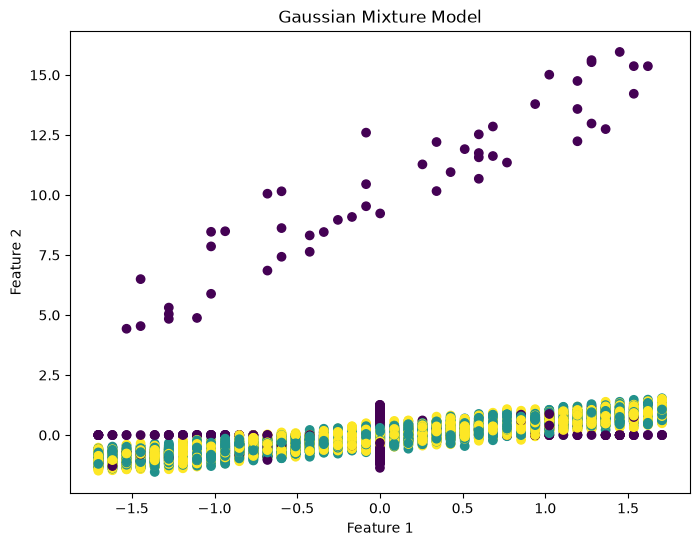

In [26]:
plt.figure(figsize=(8,6))

plt.scatter(

    X_scaled[:,0],

    X_scaled[:,1],

    c=gmm_clusters

)

plt.title("Gaussian Mixture Model")

plt.xlabel("Feature 1")

plt.ylabel("Feature 2")

plt.show()

In [27]:
final_table = pd.DataFrame({

    "Model":[

        "AdaBoost",

        "Extra Trees",

        "HistGradientBoosting"

    ],

    "Accuracy":[

        accuracy_score(y_test,ada_pred),

        accuracy_score(y_test,extra_pred),

        accuracy_score(y_test,hist_pred)

    ],

    "Mean CV Score":[

        cv_results.iloc[0,1],

        cv_results.iloc[1,1],

        cv_results.iloc[2,1]

    ],

    "Std Dev":[

        cv_results.iloc[0,2],

        cv_results.iloc[1,2],

        cv_results.iloc[2,2]

    ]

})

final_table

,Model,Accuracy,Mean CV Score,Std Dev
0,AdaBoost,0.956219,0.962189,0.003483
1,Extra Trees,0.954229,0.955597,0.003351
2,HistGradientBoosting,0.973134,0.974129,0.004390
